# Image-level DIS Discontinuity Check (device_capture_time order)

**Different approach from `implementation/codes/base_discontinuity_check.py`.**

That earlier check grouped images by `dis` and measured discontinuity in **arrival
(`timestamp`) order** (checking whether a `dis`'s constituent requests are contiguous when
*all* requests for a vehicle are laid out in the order they arrived).

This notebook instead measures discontinuity in **`device_capture_time` (dct) order**, at the
**image level**, and it is defined purely in terms of incoming *requests* (distinct `timestamp`
values) — not `dis`:

> Take two distinct request timestamps `t1` and `t2` (two separate arrivals). Pool every image
> from both requests and sort by `device_capture_time`. If every image from `t1` sorts before
> every image from `t2` (or vice versa), the two requests are cleanly separated in real capture
> time — no discontinuity. If instead the sorted order interleaves them (some `t1` images,
> then a `t2` image, then more `t1` images, ...), that interleaving is a **discontinuity**: a
> request's images did not stay contiguous when reality (device capture time) is used to order
> them.

We want, per vehicle **and** fleet-wide: the **count and percentage of images** involved in
such a discontinuity.


## Method

Checking every pair of requests directly is O(requests²) per vehicle and unnecessary — the
pairwise definition above is equivalent to a single pass over the whole vehicle's images sorted
by `device_capture_time`:

1. Sort all of a vehicle's images by `device_capture_time`.
2. Run-length encode the `timestamp` (request id) column over that sorted order — consecutive
   images sharing the same `timestamp` form one **run** (one contiguous block).
3. If a given request's images land in exactly **one** run, none of its images interleaved with
   any other request — no discontinuity for it.
4. If a request's images are split across **more than one** run, every run after its *first*
   (in dct order) is, by construction, sitting after at least one other request's images already
   started and before/after more of its own — i.e. images that broke contiguity. Every image in
   those non-first runs is counted as a **discontinuous image**.

This is exactly the pairwise condition above, just computed in one linear pass instead of a
pairwise scan: a request has >1 run **iff** at least one other request's image sorts strictly
between two of its own in dct order.

We report, both **per vehicle** and **overall (fleet-wide)**:
- image-level: count & percentage of images that are discontinuous
- request-level (secondary view): count & percentage of requests (`timestamp` values) that have
  more than one run, i.e. are "split" by another request


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)

# --- Local Mac paths ---
TOP_10K_DIR = "/Users/swapnilmane/NetraDyne/DIS_logic/top_10k"
VALID_PAIRS_FILE = "/Users/swapnilmane/NetraDyne/DIS_logic/valid_tenant_vehicle_pairs.csv"
SYSTEM_DESIGN_DIR = "/Users/swapnilmane/NetraDyne/DIS_logic/system_design"
# --- Cloud instance paths (uncomment if running there instead) ---
# TOP_10K_DIR = "/home/ubuntu/dis_analysis/top_10k"
# VALID_PAIRS_FILE = "/home/ubuntu/dis_analysis/valid_tenant_vehicle_pairs.csv"
# SYSTEM_DESIGN_DIR = "/home/ubuntu/dis_analysis/system_design"

PROCESSED_IMAGES_TEMPLATE = os.path.join(TOP_10K_DIR, "processed_csv", "processed_images_{tenant_id}_{vehicle_id}.csv")
OUTPUT_DIR = os.path.join(SYSTEM_DESIGN_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

DCT_COL = "device_capture_time"
LABEL_COL = "timestamp"
MAX_WORKERS = 8


/Users/swapnilmane/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Core metric, independent of how df was loaded -- see the toy example below for a
# worked, hand-verified check of this logic before running it at fleet scale.
def compute_discontinuity(df, dct_col=DCT_COL, label_col=LABEL_COL):
    d = df[[dct_col, label_col]].dropna()
    dropped_missing_dct = len(df) - len(d)

    if d.empty:
        return {
            "total_images": 0,
            "dropped_missing_dct": dropped_missing_dct,
            "discontinuous_images": 0,
            "discontinuous_pct": np.nan,
            "total_requests": 0,
            "affected_requests": 0,
            "affected_requests_pct": np.nan,
            "num_runs": 0,
        }

    d = d.sort_values(dct_col, kind="mergesort").reset_index(drop=True)

    labels = d[label_col].to_numpy()
    run_id = np.zeros(len(labels), dtype=np.int64)
    run_id[1:] = (labels[1:] != labels[:-1]).cumsum()
    d["_run_id"] = run_id

    run_first_label = d.groupby("_run_id")[label_col].first()
    first_run_per_label = run_first_label.reset_index().groupby(label_col)["_run_id"].min()
    d["_first_run_for_label"] = d[label_col].map(first_run_per_label)

    is_extra_run_image = d["_run_id"] != d["_first_run_for_label"]
    discontinuous_images = int(is_extra_run_image.sum())
    total_images = len(d)

    runs_per_label = d.groupby(label_col)["_run_id"].nunique()
    affected_requests = int((runs_per_label > 1).sum())
    total_requests = int(runs_per_label.shape[0])

    return {
        "total_images": total_images,
        "dropped_missing_dct": dropped_missing_dct,
        "discontinuous_images": discontinuous_images,
        "discontinuous_pct": 100.0 * discontinuous_images / total_images,
        "total_requests": total_requests,
        "affected_requests": affected_requests,
        "affected_requests_pct": 100.0 * affected_requests / total_requests,
        "num_runs": int(d["_run_id"].nunique()),
    }


In [3]:
# Worked toy example, hand-verified against the definition above.
# dct-sorted request-id sequence: t1, t1, t2, t1, t3, t2
# -> runs: [t1,t1] [t2] [t1] [t3] [t2]
# -> t1's 2nd run (1 image) and t2's 2nd run (1 image) are discontinuous -> 2 of 6 images
# -> t1 and t2 each have >1 run (affected); t3 has exactly 1 run (not affected) -> 2 of 3 requests
toy = pd.DataFrame({
    DCT_COL: [1, 2, 3, 4, 5, 6],
    LABEL_COL: ["t1", "t1", "t2", "t1", "t3", "t2"],
})
toy_result = compute_discontinuity(toy)
assert toy_result["discontinuous_images"] == 2
assert toy_result["total_images"] == 6
assert toy_result["affected_requests"] == 2
assert toy_result["total_requests"] == 3
print("Toy example sanity check passed:", toy_result)


Toy example sanity check passed: {'total_images': 6, 'dropped_missing_dct': 0, 'discontinuous_images': 2, 'discontinuous_pct': 33.333333333333336, 'total_requests': 3, 'affected_requests': 2, 'affected_requests_pct': 66.66666666666667, 'num_runs': 5}


In [4]:
def load_vehicle_df(tenant_id, vehicle_id):
    path = PROCESSED_IMAGES_TEMPLATE.format(tenant_id=tenant_id, vehicle_id=vehicle_id)
    df = pd.read_csv(path, usecols=[LABEL_COL, DCT_COL], engine="pyarrow")
    df[LABEL_COL] = pd.to_datetime(df[LABEL_COL], errors="coerce")
    df[DCT_COL] = pd.to_datetime(df[DCT_COL], errors="coerce")
    return df


def analyze_vehicle(tenant_id, vehicle_id):
    try:
        df = load_vehicle_df(tenant_id, vehicle_id)
        result = compute_discontinuity(df)
        result["error"] = None
    except Exception as e:
        result = {"error": str(e)}
    result["tenant_id"] = tenant_id
    result["vehicle_id"] = vehicle_id
    return result


In [5]:
valid_pairs_df = pd.read_csv(VALID_PAIRS_FILE)
pairs = list(valid_pairs_df[["tenant_id", "vehicle_id"]].itertuples(index=False, name=None))
print(f"{len(pairs)} (tenant_id, vehicle_id) pairs to process")

results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(analyze_vehicle, t, v): (t, v) for t, v in pairs}
    for future in tqdm(as_completed(futures), total=len(futures)):
        t, v = futures[future]
        try:
            results.append(future.result(timeout=300))
        except Exception as e:
            results.append({"tenant_id": t, "vehicle_id": v, "error": str(e)})

results_df = pd.DataFrame(results)
leading_cols = ["tenant_id", "vehicle_id"]
other_cols = [c for c in results_df.columns if c not in leading_cols]
results_df = results_df[leading_cols + other_cols]

n_errors = results_df["error"].notna().sum()
print(f"vehicles processed = {len(results_df)}, errors = {n_errors}")

vehicle_results_path = os.path.join(OUTPUT_DIR, "vehicle_level_dct_discontinuity_results.csv")
results_df.to_csv(vehicle_results_path, index=False)
print(f"Wrote {vehicle_results_path}")
results_df.head()


6364 (tenant_id, vehicle_id) pairs to process



  0%|          | 0/6364 [00:00<?, ?it/s]


  0%|          | 20/6364 [00:00<00:34, 181.31it/s]


  1%|          | 46/6364 [00:00<00:28, 223.01it/s]


  1%|          | 73/6364 [00:00<00:26, 234.87it/s]

...


 99%|█████████▉| 6313/6364 [00:24<00:00, 270.57it/s]


100%|█████████▉| 6343/6364 [00:24<00:00, 276.25it/s]


100%|██████████| 6364/6364 [00:24<00:00, 258.31it/s]

vehicles processed = 6364, errors = 1
Wrote /Users/swapnilmane/NetraDyne/DIS_logic/system_design/outputs/vehicle_level_dct_discontinuity_results.csv


,tenant_id,vehicle_id,total_images,dropped_missing_dct,discontinuous_images,discontinuous_pct,total_requests,affected_requests,affected_requests_pct,num_runs,error
0,4122,3345443,1725.0,0.0,0.0,0.0,1450.0,0.0,0.0,1450.0,None
1,4904,601083,1604.0,0.0,0.0,0.0,1337.0,0.0,0.0,1337.0,None
2,20559,1348866,23.0,0.0,0.0,0.0,16.0,0.0,0.0,16.0,None
3,5904,1978627,2028.0,0.0,0.0,0.0,1857.0,0.0,0.0,1857.0,None
4,25836,3704523,752.0,0.0,0.0,0.0,589.0,0.0,0.0,589.0,None


## Vehicle-level results

In [6]:
ok = results_df[results_df["error"].isna()].copy()
if n_errors:
    print(f"Excluding {n_errors} vehicles with errors from the analysis below:")
    display(results_df.loc[results_df["error"].notna(), ["tenant_id", "vehicle_id", "error"]].head(20))

print("\\nPer-vehicle discontinuous_pct distribution (image-level):")
display(ok["discontinuous_pct"].describe())

print("\\nPer-vehicle affected_requests_pct distribution (request-level):")
display(ok["affected_requests_pct"].describe())

ok.sort_values("discontinuous_pct", ascending=False).head(10)[
    ["tenant_id", "vehicle_id", "total_images", "discontinuous_images", "discontinuous_pct",
     "total_requests", "affected_requests", "affected_requests_pct"]
]


Excluding 1 vehicles with errors from the analysis below:


,tenant_id,vehicle_id,error
1200,14233,1079659,[Errno 2] No such file or directory: '/Users/s...


\nPer-vehicle discontinuous_pct distribution (image-level):


count    6363.000000
mean        0.000965
std         0.022326
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.229508
Name: discontinuous_pct, dtype: float64

\nPer-vehicle affected_requests_pct distribution (request-level):


count    6363.000000
mean        0.000792
std         0.014692
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.588235
Name: affected_requests_pct, dtype: float64

,tenant_id,vehicle_id,total_images,discontinuous_images,discontinuous_pct,total_requests,affected_requests,affected_requests_pct
5359,21920,1515614,976.0,12.0,1.229508,340.0,2.0,0.588235
1905,5734,3769676,1626.0,12.0,0.738007,1461.0,2.0,0.136893
463,10173,1807442,2246.0,16.0,0.712378,1994.0,2.0,0.100301
2471,19683,1277084,476.0,2.0,0.420168,192.0,1.0,0.520833
626,24776,1685963,770.0,3.0,0.389610,293.0,1.0,0.341297
2775,7473,676994,396.0,1.0,0.252525,298.0,1.0,0.335570
5745,13488,2558659,2063.0,4.0,0.193892,1859.0,2.0,0.107585
2619,5668,1264048,1135.0,2.0,0.176211,854.0,2.0,0.234192
302,26630,2970688,705.0,1.0,0.141844,304.0,1.0,0.328947
1700,3468,2534051,820.0,1.0,0.121951,229.0,1.0,0.436681


Wrote /Users/swapnilmane/NetraDyne/DIS_logic/system_design/outputs/dct_discontinuity_pct_distribution.png


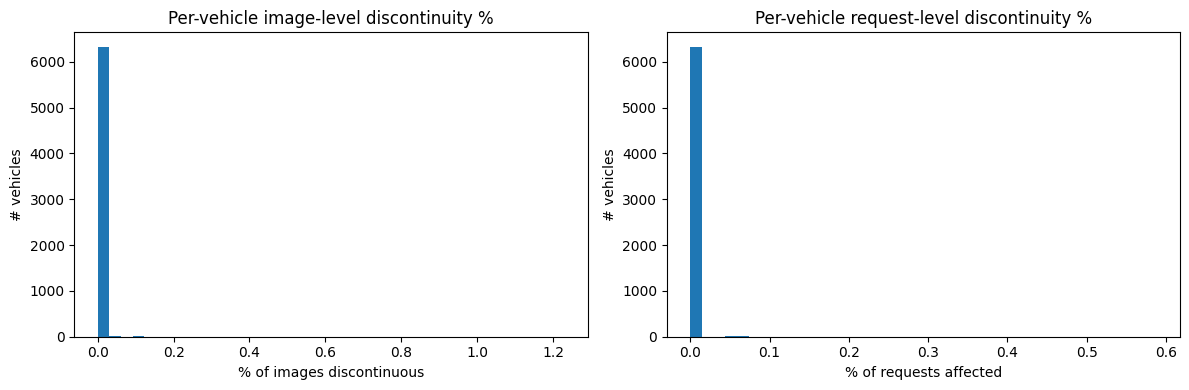

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ok["discontinuous_pct"].dropna(), bins=40)
axes[0].set_title("Per-vehicle image-level discontinuity %")
axes[0].set_xlabel("% of images discontinuous")
axes[0].set_ylabel("# vehicles")

axes[1].hist(ok["affected_requests_pct"].dropna(), bins=40)
axes[1].set_title("Per-vehicle request-level discontinuity %")
axes[1].set_xlabel("% of requests affected")
axes[1].set_ylabel("# vehicles")

fig.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "dct_discontinuity_pct_distribution.png")
fig.savefig(plot_path, dpi=150)
print(f"Wrote {plot_path}")
plt.show()


## Overall (fleet-wide) results

In [8]:
overall = {
    "vehicles_processed": int(len(ok)),
    "vehicles_with_errors": int(n_errors),
    "total_images": int(ok["total_images"].sum()),
    "discontinuous_images": int(ok["discontinuous_images"].sum()),
    # image-weighted: every image counts once, fleet-wide -- the primary headline number
    "overall_discontinuous_image_pct": 100.0 * ok["discontinuous_images"].sum() / ok["total_images"].sum(),
    # unweighted average of each vehicle's own percentage, for comparison
    "mean_of_per_vehicle_discontinuous_pct": ok["discontinuous_pct"].mean(),
    "median_of_per_vehicle_discontinuous_pct": ok["discontinuous_pct"].median(),

    "total_requests": int(ok["total_requests"].sum()),
    "affected_requests": int(ok["affected_requests"].sum()),
    "overall_affected_request_pct": 100.0 * ok["affected_requests"].sum() / ok["total_requests"].sum(),
    "mean_of_per_vehicle_affected_requests_pct": ok["affected_requests_pct"].mean(),
    "median_of_per_vehicle_affected_requests_pct": ok["affected_requests_pct"].median(),
}

overall_df = pd.DataFrame([overall])
overall_path = os.path.join(OUTPUT_DIR, "overall_dct_discontinuity_summary.csv")
overall_df.to_csv(overall_path, index=False)
print(f"Wrote {overall_path}\\n")

for k, v in overall.items():
    print(f"{k:45s} {v}")


Wrote /Users/swapnilmane/NetraDyne/DIS_logic/system_design/outputs/overall_dct_discontinuity_summary.csv\n
vehicles_processed                            6363
vehicles_with_errors                          1
total_images                                  8437627
discontinuous_images                          87
overall_discontinuous_image_pct               0.001031095591213027
mean_of_per_vehicle_discontinuous_pct         0.000964877168476514
median_of_per_vehicle_discontinuous_pct       0.0
total_requests                                6874579
affected_requests                             46
overall_affected_request_pct                  0.0006691318842942964
mean_of_per_vehicle_affected_requests_pct     0.0007919347782055278
median_of_per_vehicle_affected_requests_pct   0.0


## Notes / caveats

- **Tie-breaking**: images with an exactly-identical `device_capture_time` across different
  requests are ordered by a stable sort on original row order (`kind="mergesort"`), not
  re-sorted by anything else. This is a deliberate, documented choice, not derived from any
  ordering guarantee in the data.
- **Missing `device_capture_time`**: dropped before computing runs (`dropped_missing_dct` is
  recorded per vehicle in the results CSV) rather than treated as its own "run" or excluded from
  the denominator silently.
- This differs from `implementation/codes/base_discontinuity_check.py`'s `dis_discontinuity`
  metric in two ways: (1) ordering key is `device_capture_time` here vs. arrival `timestamp`
  order there, and (2) the unit counted here is *images*, directly, vs. that script's
  request-index-gap heuristic grouped by `dis`. The two are not directly comparable numbers.
- `valid_tenant_vehicle_pairs.csv` is reused as the vehicle universe, matching prior analyses in
  this project (a filtered subset of the full 9,635-file `top_10k/processed_csv/` corpus).
